# Verblijfsduur op de Spoedeisende Hulp visualiseren met PROC BOX

## Managementsamenvatting

Een analyse van ziekenhuisoperaties die PROC BOXPLOT (met alias PROC BOX) gebruikt om de verblijfsduur op de spoedeisende hulp te vergelijken tussen drie klinische diensten. Naast elkaar geplaatste schematische boxplots tonen in één oogopslag de mediaan, kwartielen, het gemiddelde en de langverblijvers (uitschieters) van elke dienst.

Over 100 gesimuleerde patiëntcontacten stijgt de mediane verblijfsduur gestaag van **40,0 uur bij Interne Geneeskunde** naar **50,4 uur bij Chirurgie** tot **60,5 uur bij Trauma**, en de gemiddelden volgen dezelfde volgorde (41,6, 54,6, 62,8 uur). Chirurgie kent drie hoge uitschieters boven de bovenste snorhaar (tot 84,3 uur) — de doorstroomgevallen die de meeste beduren opslokken. Het notebook trekt de vergelijking op drie manieren: een schematische plot, een overlay met gemiddelde-trend, en een horizontale opmaak.

## Gegevensbronnen

Alle gegevens worden inline gegenereerd door de eerste DATA-stap (`call streaminit(20260531)`); er wordt geen externe of netwerkinvoer gebruikt.

**`ed_los`** — één rij per patiëntcontact op de spoedeisende hulp (100 rijen)

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `PatientID` | Num | Volgnummer van patiëntcontact (1-100) |
| `Department` | Char(12) | Opnemende dienst: Interne Geneeskunde, Chirurgie, Trauma |
| `Severity` | Char(8) | Triage-urgentie: Routine (~55%), Urgent (~30%), Kritiek (~15%) |
| `LOS_Hours` | Num | Verblijfsduur in uren; een gemiddelde afhankelijk van dienst en ernst plus normale ruis, met af en toe een langverblijf-schok (gelabeld "Length of Stay (hours)") |

De gerealiseerde verdeling is Interne Geneeskunde 34 / Chirurgie 36 / Trauma 30 contacten, en Routine 51 / Urgent 35 / Kritiek 14 op triage-urgentie.

# Verblijfsduur op de Spoedeisende Hulp visualiseren met PROC BOX

Verblijfsduur (length of stay, LOS) is een van de nauwlettendst gevolgde operationele maatstaven op een spoedeisende hulp: ze bepaalt de beschikbaarheid van bedden, de personeelsinzet, de patiëntdoorstroom en de kwaliteitsscores. Gemiddelden alleen verbergen het verhaal — wat voor een operationeel team telt, is de *spreiding* van de verblijven, de *uitschieters* die middelen bezetten, en hoe de verdelingen tussen klinische diensten verschillen.

PROC BOX (een alias voor PROC BOXPLOT) is precies voor deze vergelijking gemaakt. De procedure tekent naast elkaar geplaatste box-and-whiskerplots, waarbij per groep de mediaan, kwartielen, het gemiddelde en de extreme waarnemingen worden gemarkeerd, zodat een analist de vorm van de LOS-verdeling van elke dienst in één oogopslag kan aflezen.

In dit notebook doen we het volgende:

1. Een synthetische dataset van SEH-contacten genereren die past binnen de omgeving van 100 waarnemingen.
2. Een schematische boxplot van LOS per afdeling maken, met de bijbehorende statistiektabel.
3. Een gemiddelde-trendlijn overlayen met `BOXCONNECT=MEAN` om het dienstverloop expliciet te maken.
4. Dezelfde vergelijking horizontaal opnieuw tekenen met `HORIZONTAL`.

## Stap 1 — Synthetische SEH-contactgegevens genereren

We simuleren 100 patiëntcontacten op de spoedeisende hulp. Elke patiënt wordt toegewezen aan een van drie klinische diensten (Interne Geneeskunde, Chirurgie, Trauma) en een triage-ernst (Routine, Urgent, Kritiek). De verblijfsduur wordt opgebouwd uit een dienstspecifieke basiswaarde, naar boven verschoven voor patiënten met een hogere urgentie, met normaal verdeelde ruis. Een klein deel van de contacten krijgt een extra langverblijf-schok om de zware rechterstaart na te bootsen die echte SEH-gegevens altijd vertonen (doorstroom, opnames in afwachting van een klinisch bed). De vaste seed in `call streaminit` maakt de dataset volledig reproduceerbaar.

In [1]:
OPTIES linesize=96;

GEGEVENS ed_los;
   CALL streaminit(20260531);
   LENGTE Department $ 20 Severity $ 8;
   REEKS depts[3] $ 20 _temporary_ ('Interne Geneeskunde' 'Chirurgie' 'Trauma');
   REEKS sevp[3]  $ 8  _temporary_ ('Routine' 'Urgent' 'Kritiek');
   DOE PatientID = 1 TOT 100;
      d = rand('integer', 1, 3);
      Department = depts[d];

      u = rand('uniform');
      ALS u < 0.55 DAN s = 1;
      ANDERS ALS u < 0.85 DAN s = 2;
      ANDERS s = 3;
      Severity = sevp[s];

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      ALS rand('uniform') < 0.06 DAN
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      ALS LOS_Hours < 2 DAN LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      UITVOER;
   EINDE;
   VERWIJDEREN d u s BASE;
   label LOS_Hours = 'Verblijfsduur (uren)';
UITVOEREN;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Stap 2 — Sorteren op de groepsvariabele

PROC BOX verwacht dat de groepsvariabele (horizontale as) gesorteerd is, zodat de waarnemingen voor elke groep aaneengesloten liggen. We sorteren op `Department` vóór het plotten.

In [2]:
PROCEDURE SORTEREN GEGEVENS=ed_los;
   VOLGENS Department;
UITVOEREN;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Stap 3 — Schematische boxplot

De kernanalyse. De syntaxis `PLOT analysis-var * group-var` vraagt één box per afdeling aan. `BOXSTYLE=SCHEMATIC` levert een klassieke schematische Tukey-plot: de snorharen strekken zich uit tot de meest extreme waarnemingen binnen 1,5 keer de interkwartielafstand, en alle punten daarbuiten worden afzonderlijk als uitschieters getekend — ideaal om de langverblijfgevallen op te sporen die de capaciteit onder druk zetten.

`NOHLABEL` onderdrukt het overbodige label van de horizontale as, aangezien de afdelingsnamen voor zich spreken. Naast de plot drukt PROC BOXPLOT een statistiektabel af met per afdeling de N, het minimum, de kwartielen, de mediaan, het maximum, het gemiddelde en de standaardafwijking.

                                 Verblijfsduur SEH per afdeling                                 

                                 Verblijfsduur SEH per afdeling

                                     The BOXPLOT Procedure

Schematic Plots for Verblijfsduur (uren)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interne Geneeskunde     34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verblijfsduur SEH per afdeling.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


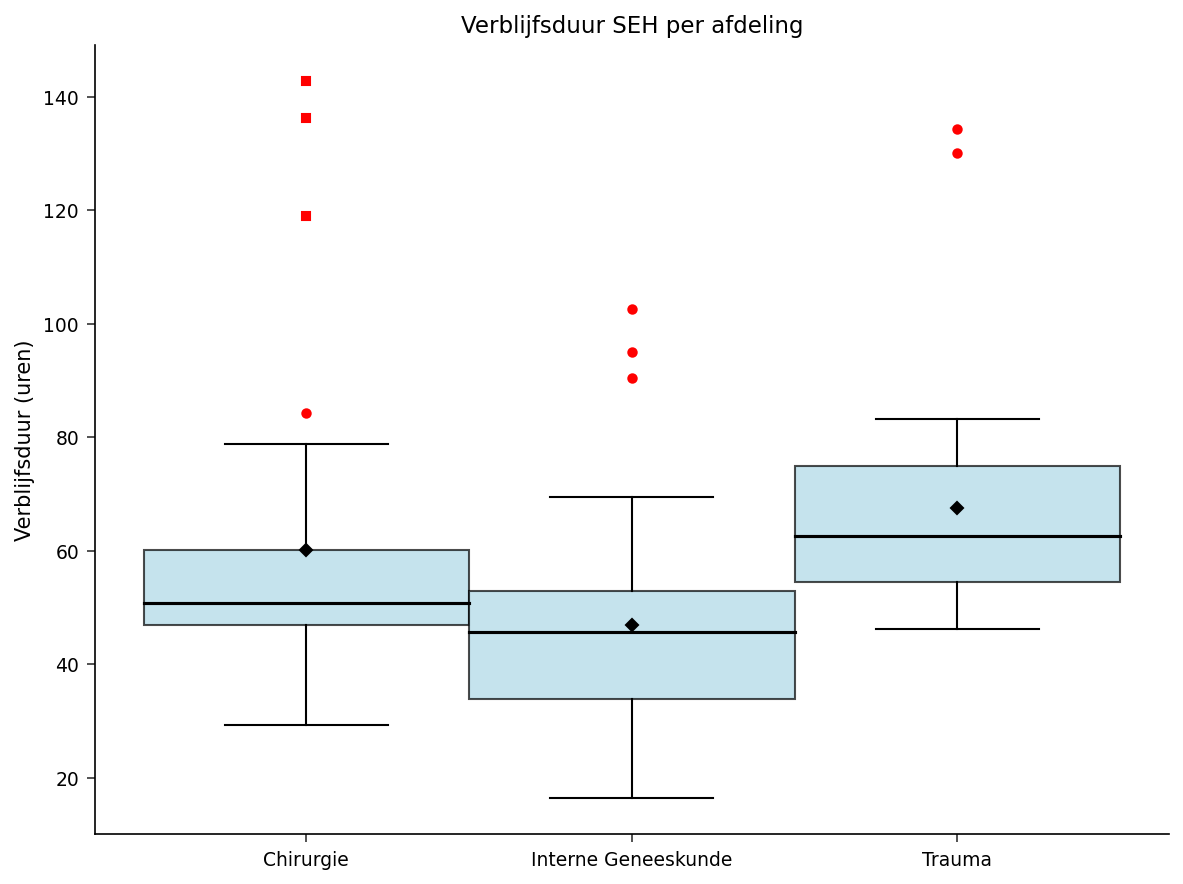

In [3]:
TITEL 'Verblijfsduur SEH per afdeling';
PROCEDURE boxplot GEGEVENS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
UITVOEREN;

## Stap 4 — Een gemiddelde-trendlijn overlayen

Om het verloop van dienst tot dienst expliciet te maken, voegen we `BOXCONNECT=MEAN` toe. PROC BOXPLOT tekent dan een verbindingslijn door het gemiddelde van elke box (de ruitmarkeringen), waardoor de drie afzonderlijke verdelingen worden omgezet in één afleesbare trend. Omdat de afdelingen geordend zijn als Interne Geneeskunde → Chirurgie → Trauma, vat de stijgende verbindingslijn de escalatie in gemiddelde verblijfsduur in één beweging samen — een nuttige aanwijzing voor een operationeel dashboard.

                       Verblijfsduur SEH per afdeling - gemiddelde-trend                        

                       Verblijfsduur SEH per afdeling - gemiddelde-trend

                                     The BOXPLOT Procedure

Schematic Plots for Verblijfsduur (uren)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interne Geneeskunde     34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verblijfsduur SEH per afdeling - gemiddelde-trend.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


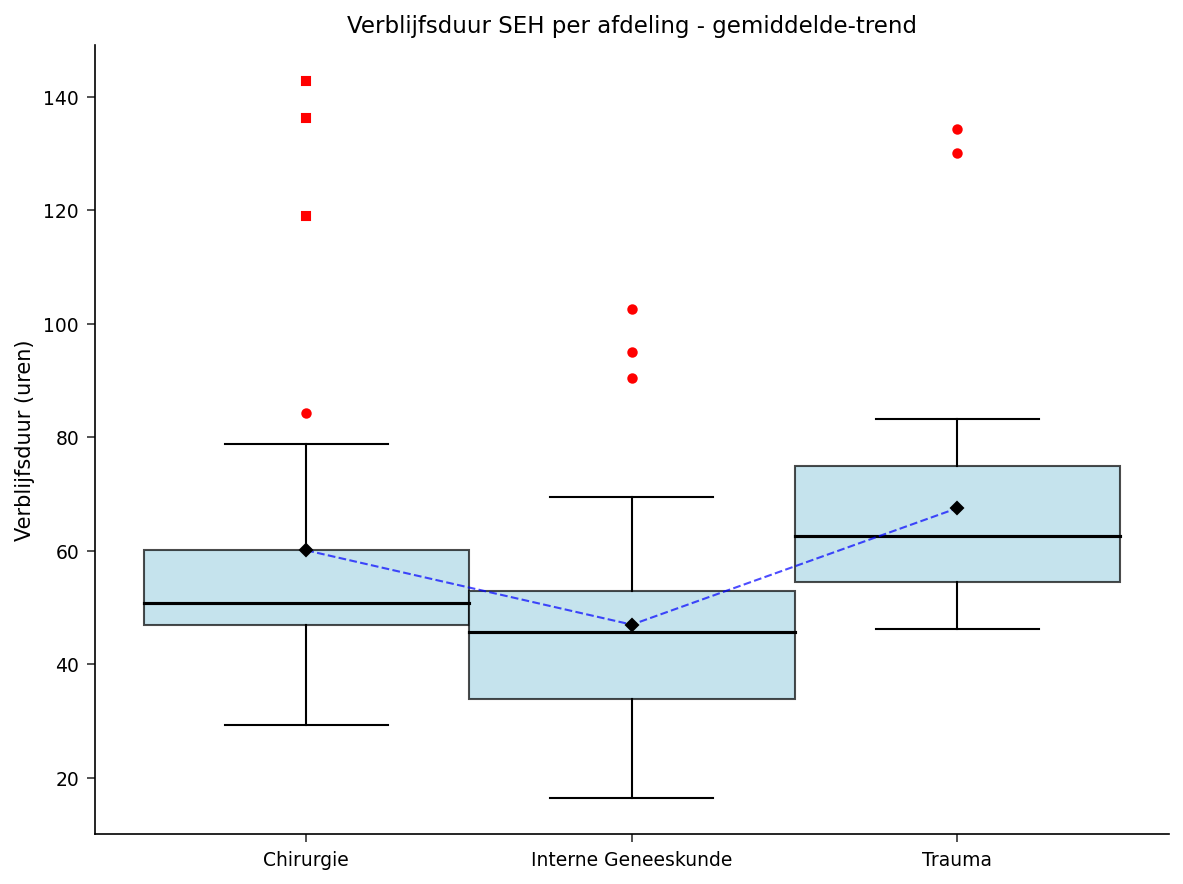

In [4]:
TITEL 'Verblijfsduur SEH per afdeling - gemiddelde-trend';
PROCEDURE boxplot GEGEVENS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
UITVOEREN;

## Stap 5 — Horizontale opmaak

Dezelfde vergelijking leest van nature goed op de zijkant. Door `HORIZONTAL` toe te voegen wisselen de assen om, zodat de boxen van links naar rechts lopen met de respons op de x-as — een opmaak die beter schaalt wanneer dienstnamen lang of talrijk zijn, en die veel operationele dashboards verkiezen. De statistieken zijn identiek aan de verticale weergave; alleen de oriëntatie verandert.

                          Verblijfsduur SEH per afdeling - horizontaal                          

                          Verblijfsduur SEH per afdeling - horizontaal

                                     The BOXPLOT Procedure

Schematic Plots for Verblijfsduur (uren)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgie            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Interne Geneeskunde     34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Verblijfsduur SEH per afdeling - horizontaal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


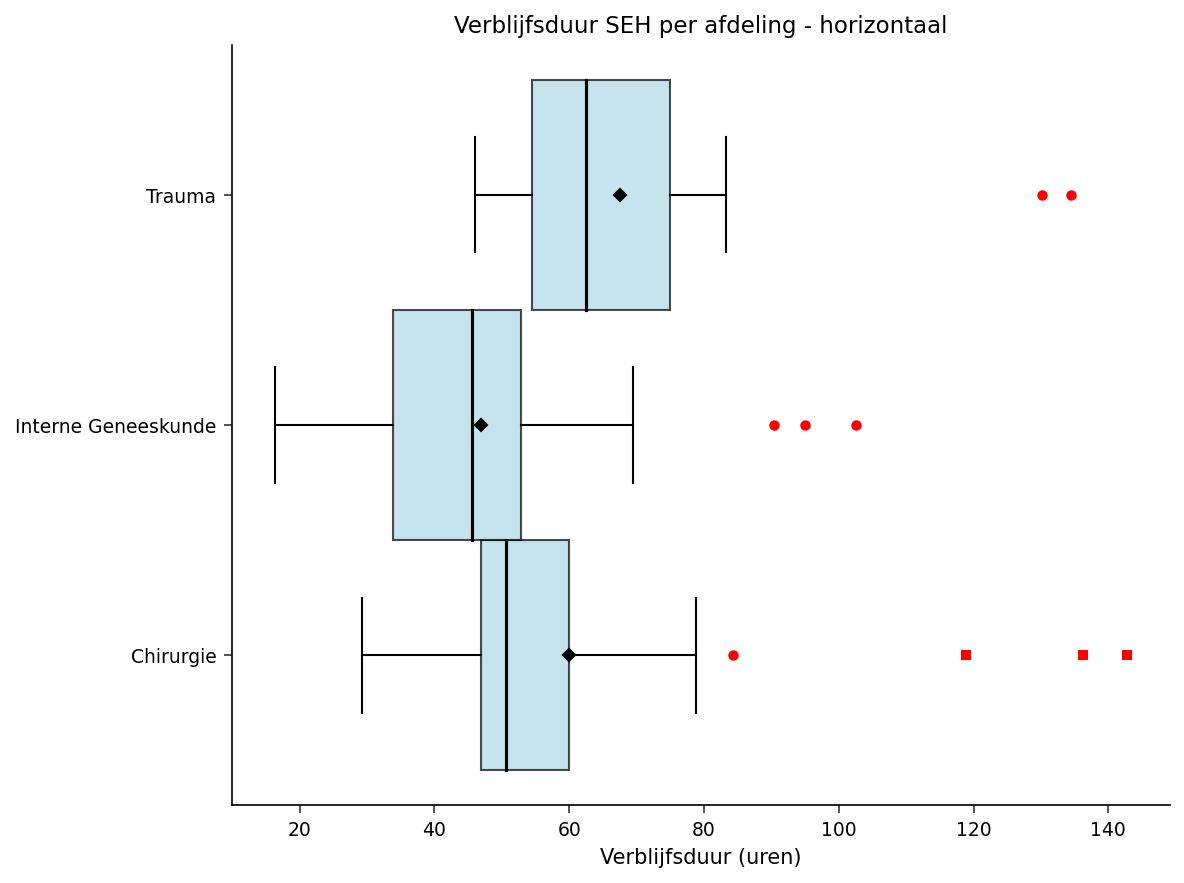

In [5]:
TITEL 'Verblijfsduur SEH per afdeling - horizontaal';
PROCEDURE boxplot GEGEVENS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
UITVOEREN;

## De resultaten interpreteren

De boxplots en de bijbehorende statistiektabel vertalen de ruwe LOS-gegevens naar een operationeel bruikbaar beeld:

- **Een duidelijk dienstverloop.** De mediane verblijfsduur stijgt monotoon over de drie diensten: **Interne Geneeskunde 40,0 u → Chirurgie 50,4 u → Trauma 60,5 u**. De gemiddelden vertellen hetzelfde verhaal (41,6, 54,6, 62,8 u), en de `BOXCONNECT=MEAN`-lijn in Stap 4 tekent die escalatie als één stijgende trend. Traumapatiënten verblijven gemiddeld ongeveer 50% langer dan patiënten van Interne Geneeskunde.

- **Variabiliteit telt evenzeer als de mediaan.** De interkwartielafstand (de hoogte van de box) is het breedst voor Interne Geneeskunde (Q1 32,8 u tot Q3 51,2 u, een spreiding van 18,3 uur) en het smalst voor Trauma (Q1 54,5 u tot Q3 68,5 u, een spreiding van 14,0 uur). Interne Geneeskunde is daarom niet alleen de kortste dienst maar ook de minst voorspelbare — de eigenschap die prognoses voor bedbeheer bemoeilijkt.

- **Uitschieters markeren de doorstroomgevallen.** De schematische snorharen stoppen bij 1,5 × IQR, dus de drie rode punten boven de bovenste snorhaar van Chirurgie (met een piek op 84,3 u) springen eruit als echte langverblijfcontacten — precies de doorstroomgevallen die onevenredig veel beduren opslokken. Interne Geneeskunde en Trauma tonen in deze steekproef geen punten buiten hun snorharen.

- **De spreidingsbreedte vertelt het verhaal van de capaciteitsplanning.** Waargenomen verblijven lopen van 16,3–69,5 u bij Interne Geneeskunde, 29,3–84,3 u bij Chirurgie, en 46,1–83,2 u bij Trauma. Trauma levert nooit een kort verblijf op (het minimum, 46,1 u, overschrijdt de mediaan van Interne Geneeskunde), wat een operationeel team ook zou verwachten van de meest middelenintensieve dienst.

Samen bieden deze weergaven een leiding van een spoedeisende hulp een verdedigbare, verdelingsbewuste basis voor personeels- en capaciteitsplanning — veel informatiever dan het louter vergelijken van de gemiddelde LOS per afdeling.